In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.processing import WESADDataset
from src.features import process_subject_data

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

In [2]:
loader = WESADDataset('../data/WESAD')
df_raw = loader.load_subject('S2')
df     = loader.filter_target_states(df_raw)

feature_df = process_subject_data(df)

# Separate features from label
X = feature_df.drop('Label', axis=1).values
y = feature_df['Label'].values
feature_names = feature_df.drop('Label', axis=1).columns.tolist()

print(f"Feature matrix: {X.shape}")
print(f"Label distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

Loading S2 data... This might take a moment.
Extracting features using 60-second windows...
Feature matrix: (29, 7)
Label distribution: {np.int64(0): np.int64(19), np.int64(1): np.int64(10)}


In [3]:
# Features have very different scales:
# HRV_RMSSD ~ 40-110ms, Temp_Mean ~ 28-32°C, EDA_Tonic ~ 0-5µS
# SVM is sensitive to this — we must standardize
# Random Forest is NOT sensitive to scale, but we scale anyway for consistency

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling — first row:")
print(dict(zip(feature_names, X[0].round(4))))
print("\nAfter scaling — first row:")
print(dict(zip(feature_names, X_scaled[0].round(4))))

Before scaling — first row:
{'HRV_RMSSD': np.float64(65.9926), 'HRV_MeanNN': np.float64(742.8036), 'Mean_HR': np.float64(80.7597), 'EDA_Tonic_Mean': np.float64(4.9365), 'EDA_Phasic_Mean': np.float64(-0.0025), 'Temp_Mean': np.float64(29.1566), 'Resp_Std': np.float64(2.8228)}

After scaling — first row:
{'HRV_RMSSD': np.float64(0.4078), 'HRV_MeanNN': np.float64(-1.8429), 'Mean_HR': np.float64(1.8618), 'EDA_Tonic_Mean': np.float64(3.1685), 'EDA_Phasic_Mean': np.float64(-3.4598), 'Temp_Mean': np.float64(-0.3806), 'Resp_Std': np.float64(0.4798)}


In [4]:
# With only ~20-30 windows, a single train/test split is unreliable
# StratifiedKFold ensures each fold has balanced class proportions
# We use 5 folds — standard in small-sample research

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)'    : SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    scores = cross_validate(
        model, X_scaled, y, cv=cv,
        scoring=['accuracy', 'f1', 'precision', 'recall'],
        return_train_score=False
    )
    results[name] = {
        'Accuracy' : scores['test_accuracy'].mean(),
        'F1'       : scores['test_f1'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall'   : scores['test_recall'].mean(),
        'Acc Std'  : scores['test_accuracy'].std()
    }
    print(f"\n{name}:")
    print(f"  Accuracy  : {results[name]['Accuracy']:.3f} ± {results[name]['Acc Std']:.3f}")
    print(f"  F1 Score  : {results[name]['F1']:.3f}")
    print(f"  Precision : {results[name]['Precision']:.3f}")
    print(f"  Recall    : {results[name]['Recall']:.3f}")


Random Forest:
  Accuracy  : 0.933 ± 0.082
  F1 Score  : 0.920
  Precision : 0.867
  Recall    : 1.000

SVM (RBF):
  Accuracy  : 0.900 ± 0.082
  F1 Score  : 0.880
  Precision : 0.800
  Recall    : 1.000


In [ ]:
# Add this as a markdown cell — type it, don't run it as code

"""
## Why We Report F1, Not Just Accuracy

If 70% of windows are baseline and 30% are stress,
a model that always predicts 'baseline' gets 70% accuracy
but completely fails at detecting stress — which is the whole point.

F1 score balances precision (when we predict stress, are we right?)
and recall (of all actual stress windows, how many did we catch?).
A high F1 means the model is genuinely discriminating, not cheating.
"""

              precision    recall  f1-score   support

    Baseline       1.00      1.00      1.00        19
      Stress       1.00      1.00      1.00        10

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



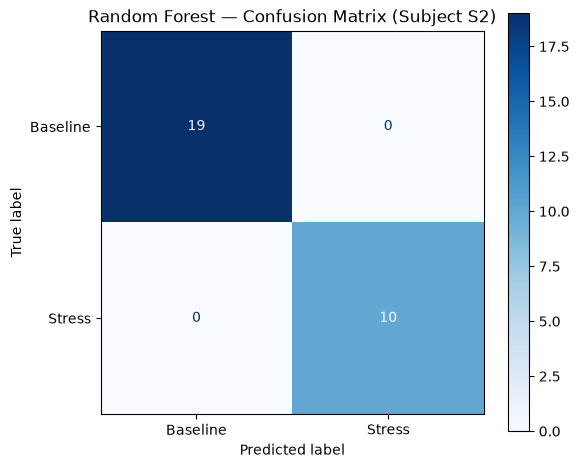

In [5]:
# Train Random Forest on full dataset for visualization
# (In production you would use a held-out test set)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

y_pred = rf.predict(X_scaled)

print(classification_report(y, y_pred,
      target_names=['Baseline', 'Stress']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred,
    display_labels=['Baseline', 'Stress'],
    cmap='Blues', ax=ax
)
ax.set_title('Random Forest — Confusion Matrix (Subject S2)', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150)
plt.show()